In [1]:
from google.colab import drive
import sys

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Link custom scripts folder path
sys.path.append('/content/drive/MyDrive/Freight_Cost_Project/freight_cost_prediction')


Mounted at /content/drive


In [2]:
# Flagging Vendor Invoices for Manual Review
# Objective: Predict whether a vendor invoice should be flagged for manual approval based on abnormal cost, freight, or delivery patterns, in order to reduce
# financial risk, improve operational efficiency, and prioritize human review where it adds the most value.

# . Manual invoice review is time-consuming and does not scale with transaction volume.
# . Abnormal freight charges, pricing deviations, or delivery delays often indicate errors, disputes, or compliance risks.
# . An automated flagging system enables finance teams to focus attention on high-risk invoices while allowing low-risk invoices to be processed automatically.

In [3]:


import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
conn = sqlite3.connect('/content/drive/MyDrive/Freight_Cost_Project/inventory.db')

In [7]:
tabled = pd.read_sql_query("select name from sqlite_master where type= 'table'", conn)

In [8]:
tabled

,name
0,purchases
1,purchase_prices
2,vendor_invoice
3,begin_inventory
4,end_inventory


In [11]:
tables = tabled['name'].tolist()

In [13]:
for table  in tables:
  print(f"Table name: {table}")
  df = pd.read_sql_query(f"select * from {table}", conn)
  print(df.head())

Table name: purchases
           InventoryId  Store  Brand                   Description   Size  \
0    69_MOUNTMEND_8412     69   8412     Tequila Ocho Plata Fresno  750mL   
1     30_CULCHETH_5255     30   5255  TGI Fridays Ultimte Mudslide  1.75L   
2    34_PITMERDEN_5215     34   5215  TGI Fridays Long Island Iced  1.75L   
3  1_HARDERSFIELD_5255      1   5255  TGI Fridays Ultimte Mudslide  1.75L   
4    76_DONCASTER_2034     76   2034     Glendalough Double Barrel  750mL   

   VendorNumber                   VendorName  PONumber      PODate  \
0           105  ALTAMAR BRANDS LLC               8124  2023-12-21   
1          4466  AMERICAN VINTAGE BEVERAGE        8137  2023-12-22   
2          4466  AMERICAN VINTAGE BEVERAGE        8137  2023-12-22   
3          4466  AMERICAN VINTAGE BEVERAGE        8137  2023-12-22   
4           388  ATLANTIC IMPORTING COMPANY       8169  2023-12-24   

  ReceivingDate InvoiceDate     PayDate  PurchasePrice  Quantity  Dollars  \
0    2024-01-02  

In [17]:
purchase_agg_df=pd.read_sql_query(
"""select
p.PONumber,
count(distinct p.Brand) as total_brands,
sum(p.Quantity) as total_item_quantity,
sum(p.Dollars) as total_item_dollars,
avg(julianday(p.ReceivingDate) - julianday(p.PODate)) as avg_receiving_delay
from purchases p
group by p. PONumber""", conn)

In [21]:
pd.read_sql_query(
"""select *
from vendor_invoice vi
""",conn)

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None
...,...,...,...,...,...,...,...,...,...,...
5538,9622,WEIN BAUER INC,2025-01-06,13626,2024-12-21,2025-02-10,90,1563.00,8.60,None
5539,9625,WESTERN SPIRITS BEVERAGE CO,2025-01-10,13661,2024-12-23,2025-02-18,4617,37300.48,186.50,None
5540,3664,WILLIAM GRANT & SONS INC,2025-01-02,13643,2024-12-22,2025-02-04,9848,202815.78,932.95,None
5541,9815,WINE GROUP INC,2025-01-03,13602,2024-12-20,2025-02-08,24747,149007.56,819.54,None


In [23]:
pd.read_sql_query(
"""select
vi.Quantity as invoice_quantity,
vi.Dollars as invoice_dollars,
vi.Freight,
(julianday(vi.InvoiceDate) - julianday(vi.PODate)) AS days_po_to_invoice,
(julianday(vi.PayDate) - julianday(vi.InvoiceDate)) AS days_to_pay
from vendor_invoice vi""", conn)

,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay
0,6,214.26,3.47,14.0,43.0
1,15,140.55,8.57,16.0,45.0
2,5,106.60,4.61,16.0,38.0
3,10100,137483.78,2935.20,23.0,24.0
4,1935,15527.25,429.20,14.0,36.0
...,...,...,...,...,...
5538,90,1563.00,8.60,16.0,35.0
5539,4617,37300.48,186.50,18.0,39.0
5540,9848,202815.78,932.95,11.0,33.0
5541,24747,149007.56,819.54,14.0,36.0


In [24]:
invoice_flagging_df = pd.read_sql_query("""
WITH purchase_agg AS (
    SELECT
        p.PONumber,
        COUNT(DISTINCT p.Brand) AS total_brands,
        SUM(p.Quantity) AS total_item_quantity,
        SUM(p.Dollars) AS total_item_dollars,
        AVG(julianday(p.ReceivingDate) - julianday(p.PODate)) AS avg_receiving_delay
    FROM purchases p
    GROUP BY p.PONumber
)

SELECT
    vi.PONumber,
    vi.Quantity AS invoice_quantity,
    vi.Dollars AS invoice_dollars,
    vi.Freight,
    (julianday(vi.InvoiceDate) - julianday(vi.PODate)) AS days_po_to_invoice,
    (julianday(vi.PayDate) - julianday(vi.InvoiceDate)) AS days_to_pay,
    pa.total_brands,
    pa.total_item_quantity,
    pa.total_item_dollars,
    pa.avg_receiving_delay
FROM vendor_invoice vi
LEFT JOIN purchase_agg pa
    ON vi.PONumber = pa.PONumber
""", conn)


In [26]:
invoice_flagging_df

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8124,6,214.26,3.47,14.0,43.0,1,6,214.26,12.000000
1,8137,15,140.55,8.57,16.0,45.0,2,15,140.55,10.333333
2,8169,5,106.60,4.61,16.0,38.0,1,5,106.60,9.000000
3,8106,10100,137483.78,2935.20,23.0,24.0,81,10100,137483.78,12.614130
4,8170,1935,15527.25,429.20,14.0,36.0,29,1935,15527.25,8.752809
...,...,...,...,...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0,2,223,6823.18,5.871795
5539,13661,4617,37300.48,186.50,18.0,39.0,110,24747,149007.56,5.050500
5540,13643,9848,202815.78,932.95,11.0,33.0,5,180,2559.72,5.000000
5541,13602,24747,149007.56,819.54,14.0,36.0,83,43240,318075.65,8.045541


In [27]:
invoice_flagging_df.isnull().sum()

,0
PONumber,0
invoice_quantity,0
invoice_dollars,0
Freight,0
days_po_to_invoice,0
days_to_pay,0
total_brands,0
total_item_quantity,0
total_item_dollars,0
avg_receiving_delay,0


In [28]:
invoice_flagging_df.dtypes

,0
PONumber,int64
invoice_quantity,int64
invoice_dollars,float64
Freight,float64
days_po_to_invoice,float64
days_to_pay,float64
total_brands,int64
total_item_quantity,int64
total_item_dollars,float64
avg_receiving_delay,float64


In [30]:
# rule to flag invoices as risky (1) or safe (0)
def create_invoice_risk_label(row):

    # Invoice total mismatch with item-level total
    if (abs(row["invoice_dollars"] - row["total_item_dollars"])) > 5:
        return 1

    # Abnormally high receiving delay
    if row["avg_receiving_delay"] > 10:
        return 1

    return 0

df["flag_invoice"] = invoice_flagging_df.apply(create_invoice_risk_label, axis=1)
df["flag_invoice"].value_counts()


,count
flag_invoice,
0.0,3693
1.0,1850


<Axes: xlabel='flag_invoice'>

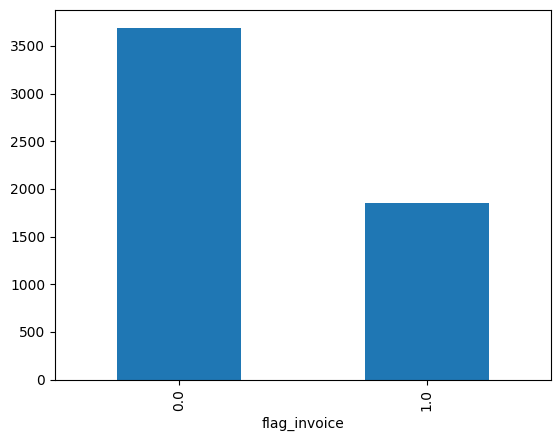

In [31]:
df['flag_invoice'].value_counts().plot(kind = 'bar')

<Axes: >

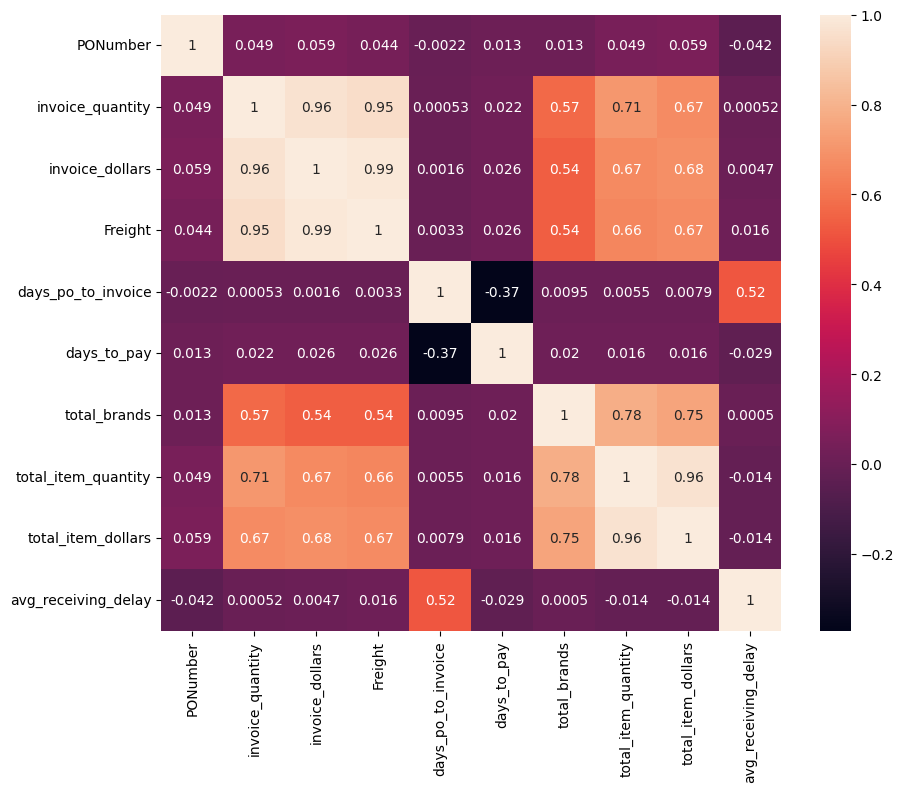

In [35]:
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(invoice_flagging_df.corr(), annot=True)

In [38]:
flagged = invoice_flagging_df[invoice_flagging_df['flag_invoice'] == 1]
normal = invoice_flagging_df[invoice_flagging_df['flag_invoice'] == 0]


In [39]:
metrics = [
    'invoice_quantity',
    'invoice_dollars',
    'Freight',
    'days_po_to_invoice',
    'days_to_pay',
    'total_brands',
    'total_item_quantity',
    'total_item_dollars',
    'avg_receiving_delay'
]


In [41]:
from scipy.stats import ttest_ind

# Initialize lists to avoid NameError
significant_features = []
non_significant_features = []
results = []

for metric in metrics:
    flagged_mean = flagged[metric].mean()
    normal_mean = normal[metric].mean()

    t_stat, p_value = ttest_ind(
        flagged[metric].dropna(),
        normal[metric].dropna(),
        equal_var=False
    )

    if p_value < 0.05:
        significant_features.append(metric)
        results.append({
            "metric": metric,
            "flagged_mean": flagged_mean.round(2),
            "normal_mean": normal_mean.round(2),
            "p_value": p_value.round(3)
        })
    else:
        non_significant_features.append(metric)

In [42]:
non_significant_features

['days_to_pay', 'total_brands']

In [44]:
X = invoice_flagging_df[['invoice_quantity', 'invoice_dollars', 'Freight', 'total_brands', 'total_item_quantity', 'days_po_to_invoice', 'total_item_dollars']]
y = invoice_flagging_df['flag_invoice']

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [49]:
from sklearn. linear_model import LogisticRegression
from sklearn. tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [76]:
model1 = LogisticRegression(random_state=42)
model1.fit(X_train_scaled, y_train)

model2 = DecisionTreeClassifier(random_state = 42)
model2.fit(X_train_scaled, y_train)

model3 = RandomForestClassifier(random_state = 42)
model3.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [93]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def print_classification_report(model, X_test, y_test, model_name):
    """
    Directly calculates and prints classification metrics in the notebook.
    """
    # 1. Generate predictions from the model
    preds = model.predict(X_test)

    # 2. Compute the exact classification statistics
    accuracy = accuracy_score(y_test, preds) * 100
    precision = precision_score(y_test, preds, zero_division=0) * 100
    recall = recall_score(y_test, preds, zero_division=0) * 100
    f1 = f1_score(y_test, preds, zero_division=0) * 100

    # 3. Print out the structured summary report
    print(f"Model: {model_name}")
    print(f"Accuracy : {accuracy:.2f}%")
    print(f"Precision: {precision:.2f}%")
    print(f"Recall   : {recall:.2f}%")
    print(f"F1 Score : {f1:.2f}%")
    print("-" * 35)

# --- RUN THE EVALUATION FOR YOUR CHOSEN MODELS ---
try:
    print_classification_report(model1, X_test_scaled, y_test, 'Logistic Regression')
    print_classification_report(model2, X_test_scaled, y_test, 'Decision Tree Classifier')
    print_classification_report(model3, X_test_scaled, y_test, 'Random Forest Classifier')
except NameError as e:
    print(f"\n❌ NameError caught: {e}")
    print("👉 Quick Fix: Scroll up slightly and rerun the cell where you trained your model1, model2, and model3 variables first!")


Model: Logistic Regression
Accuracy : 67.18%
Precision: 57.89%
Recall   : 5.95%
F1 Score : 10.78%
-----------------------------------
Model: Decision Tree Classifier
Accuracy : 81.88%
Precision: 73.54%
Recall   : 71.35%
F1 Score : 72.43%
-----------------------------------
Model: Random Forest Classifier
Accuracy : 87.56%
Precision: 92.34%
Recall   : 68.38%
F1 Score : 78.57%
-----------------------------------


In [105]:
%%writefile app.py
import streamlit as st
import pandas as pd
import pickle
import numpy as np
from pathlib import Path

st.set_page_config(page_title="Invoice Risk Audit Dashboard", page_icon="🚨", layout="wide")
st.title("🚨 Automated Vendor Invoice Risk Auditor")
st.markdown("Upload your monthly vendor billing spreadsheets below to scan for anomalies.")

model_path = Path("/content/drive/MyDrive/Freight_Cost_Project/models/best_invoice_classifier.pkl")

uploaded_file = st.file_uploader("Choose a fresh invoice CSV file to scan...", type=["csv"])

if uploaded_file is not None:
    df = pd.read_csv(uploaded_file)
    st.subheader("📊 Raw Incoming Data Preview")
    st.dataframe(df.head(5))

    if st.button("🚀 Run Machine Learning Risk Scan"):
        with st.spinner("Analyzing data..."):
            with open(model_path, "rb") as f:
                classifier = pickle.load(f)

            df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
            df['Dollars'] = pd.to_numeric(df['Dollars'], errors='coerce')
            df['Freight'] = pd.to_numeric(df['Freight'], errors='coerce')
            df = df.fillna(0)

            X_live = df[['Quantity', 'Dollars', 'Freight']]
            df['Risk_Flag'] = classifier.predict(X_live)
            anomalies = df[df['Risk_Flag'] == 1]

            st.success("✨ Audit complete!")
            st.metric(label="Total Invoices Scanned", value=len(df))
            st.metric(label="High-Risk Anomalies Flagged", value=len(anomalies))

            if len(anomalies) > 0:
                st.dataframe(anomalies)


Writing app.py


In [106]:
!pip install streamlit -q
!streamlit run app.py
y



2026-10-07 11:07:16.193 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://104.155.200.11:8501

  Stopping...
  Stopping...


In [107]:
!npx localtunnel --port 8501


⠙⠹⠸⠼⠴⠦⠧⠇⠏Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) y

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇your url is: https://famous-cobras-fry.loca.lt
^C


In [108]:
import os
import threading

# 1. Force the Streamlit server to run silently in the absolute background
def run_streamlit():
    os.system("streamlit run app.py --server.port 8501 --server.address 104.155.200.11")

# Start the background thread loop
threading.Thread(target=run_streamlit, daemon=True).start()
print("🚀 Streamlit engine successfully shifted to the cloud background!")


🚀 Streamlit engine successfully shifted to the cloud background!


In [111]:
import os
import threading

# Shut down old stray server instances if any exist
os.system("pkill streamlit")

# Run Streamlit in the absolute background of your Colab cloud instance
def launch_app():
    os.system("streamlit run app.py --server.port 8501")

threading.Thread(target=launch_app, daemon=True).start()
print("🚀 Live Dashboard UI is successfully active!")


🚀 Live Dashboard UI is successfully active!


In [113]:
!pip install streamlit -q
!nohup streamlit run app.py --server.port 8501 &


nohup: appending output to 'nohup.out'


In [ ]:
!npx localtunnel --port 8501


⠙⠹⠸⠼⠴⠦⠧⠇⠏your url is: https://whole-rice-try.loca.lt
